# Miracle Invoker
### Team Member
1. Puran Karki
2. Pravesh Bahakari
3. Nabin Yari
4. Manoj Bhattarai

The dataset selected for this project is the *E-Commerce Online Retail dataset*, which contains real transactions data from a UK-based online store. It has over 500,000 rows of records which make suitable for the Big Data analytic. 
This dataset is choosen because it is large, realistic and well structured which allow us to analyze customer behaviour, sales trands and product performance.

## Setup & Import
Install and import the necessary libraries for Spark and MongoDb

In [2]:
# Install necessary packages
%pip install pyspark pymongo dnspython

import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, when, desc, rank
from pyspark.sql.window import Window
import pymongo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


## Spark Session Initialization

In this step, we start Spark so we can work with our data.

We first import `SparkSession` and then create a Spark session using the builder.

- appName("BigDataProject") just gives a name to our project.
- master("local[*]" means Spark will run on our computer and use all available CPU cores.
- config("spark.driver.host", "127.0.0.1") helps Spark run properly on the local machine.

The `getOrCreate()` function creates a new Spark session if one does not exist, or uses the existing one.

This step is important because we need the Spark session before we can load and analyze any data.

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BigDataProject") \
    .master("local[*]") \
    .config("spark.driver.host", "127.0.0.1") \
    .getOrCreate()

print("Spark started successfully")

Spark started successfully


## Loading dataset with header

In this step, we load the dataset into Spark using the `read.csv()` function. We use header=True so that the first row is treated as column names, and inferSchema=True so Spark can automatically detect the correct data types.

After loading the data, we use show(5) to display the first five rows. This helps us quickly check if the data has been loaded correctly.

We also use `printSchema()` to see the structure of the dataset, including column names and their data types. This is useful for understanding the data before cleaning and analysis.

In [4]:
online_df = spark.read.csv("data.csv", header=True, inferSchema=True)

online_df.show(5) #display top 5 row of data
online_df.printSchema() #display the table

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
only showing top 5 rows
root
 |-- InvoiceNo: string (nullable = true)
 |-

## Basic cleaning of Data
In this step, we clean the dataset to make sure the analysis is more accurate.

First, we use `dropna()` to remove any rows that contain missing values in any column. This helps us avoid problems caused by incomplete data.

Then, we filter the dataset to keep only rows where the Quantity is greater than 0. This removes invalid records such as returns or incorrect entries.

Finally, we use `show(5)` to display a few rows and check that the cleaned data looks correct.

In [5]:
new_online_df = online_df.dropna() #remove all the row which have null value in any column
df = new_online_df.filter(new_online_df["Quantity"] > 0) #remove quantity which are less or equal to 0
df.show(5)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
only showing top 5 rows


## Simple analysis with spark SQL

### Sales analysis by country
In this step, we analyze how sales are distributed across different countries.

First, we create a temporary view called "sales" using `createOrReplaceTempView()`. This allows us to run SQL queries on the DataFrame.

Then, we use a Spark SQL query to group the data by country and calculate the total quantity sold in each country using `SUM(Quantity)`.

The results are sorted in descending order so that countries with the highest sales appear at the top.

We use `show()` to display the result in Spark, and then convert it to a Pandas DataFrame using `toPandas()` so that we can use it later for visualization.

In [6]:
df.createOrReplaceTempView("sales")

In [7]:
result = spark.sql("""
SELECT Country, SUM(Quantity) as Total_Quantity
FROM sales
GROUP BY Country
ORDER BY Total_Quantity DESC
""")

result.show()
pdf = result.toPandas()

+---------------+--------------+
|        Country|Total_Quantity|
+---------------+--------------+
| United Kingdom|       4269472|
|    Netherlands|        200937|
|           EIRE|        140525|
|        Germany|        119263|
|         France|        111472|
|      Australia|         84209|
|         Sweden|         36083|
|    Switzerland|         30083|
|          Spain|         27951|
|          Japan|         26016|
|        Belgium|         23237|
|         Norway|         19338|
|       Portugal|         16122|
|        Finland|         10704|
|Channel Islands|          9491|
|        Denmark|          8235|
|          Italy|          8112|
|         Cyprus|          6361|
|      Singapore|          5241|
|        Austria|          4881|
+---------------+--------------+
only showing top 20 rows


### Visualization of sales by country

Here, we visualize the countries with the highest sales.

First, we sort the data based on total quantity in descending order and select the top 10 countries. This helps us focus on the most important results.

Then, we create a bar chart using Matplotlib. The x-axis represents the countries, and the y-axis shows the total quantity sold.

We rotate the x-axis labels to make them easier to read and adjust the layout so everything fits properly.

Finally, we display the chart to clearly compare sales across different countries.

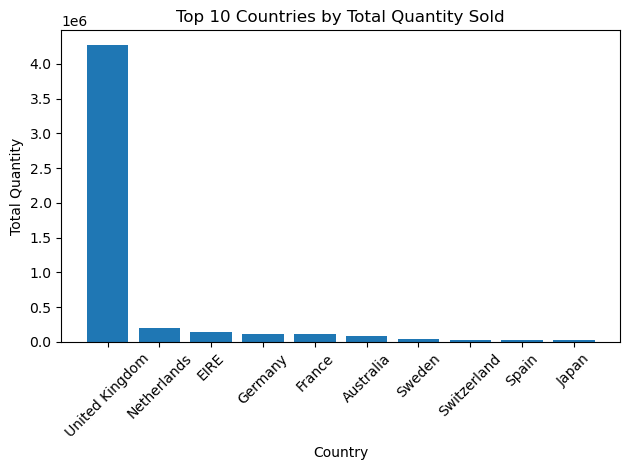

In [8]:
# Sort and take top 10 countries (cleaner graph)
pdf = pdf.sort_values(by="Total_Quantity", ascending=False).head(10)

plt.figure()
plt.bar(pdf["Country"], pdf["Total_Quantity"])
plt.title("Top 10 Countries by Total Quantity Sold")
plt.xlabel("Country")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Top Selling Products

Here, we find the products which are sold the most.

We use a Spark SQL query to group the data by product description and calculate the total quantity sold using `SUM(Quantity)`. The results are sorted in descending order so that the best-selling products appear first. We limit the output to the top 10 products.

We display the result using `show()` and convert it into a Pandas DataFrame using `toPandas()` for visualization.

In [9]:
result = spark.sql("""
SELECT Description, SUM(Quantity) as Total_Sold
FROM sales
GROUP BY Description
ORDER BY Total_Sold DESC
LIMIT 10
""")

result.show()
pdf = result.toPandas()

+--------------------+----------+
|         Description|Total_Sold|
+--------------------+----------+
|PAPER CRAFT , LIT...|     80995|
|MEDIUM CERAMIC TO...|     77916|
|WORLD WAR 2 GLIDE...|     54415|
|JUMBO BAG RED RET...|     46181|
|WHITE HANGING HEA...|     36725|
|ASSORTED COLOUR B...|     35362|
|PACK OF 72 RETROS...|     33693|
|      POPCORN HOLDER|     30931|
|  RABBIT NIGHT LIGHT|     27202|
|MINI PAINT SET VI...|     26076|
+--------------------+----------+



### Visualization of top selling products

Now, we create a bar chart to visualize the top selling products.

The product descriptions are shown on one axis, and the total quantity sold is shown on the other. We invert the axis so that the product with the highest sales appears at the top, making the chart easier to read.

This visualization helps us quickly identify which products are the most popular.

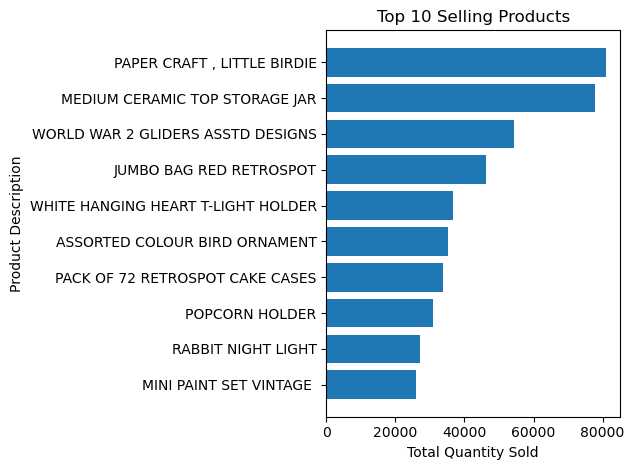

In [10]:
plt.figure()
plt.barh(pdf["Description"], pdf["Total_Sold"])
plt.title("Top 10 Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Description")

plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()

plt.show()

### Country generates the most money/ revenue

In this step, we calculate how much revenue each country generates.
We use a Spark SQL query to group the data by country and calculate revenue using `SUM(Quantity * UnitPrice)`. This gives us the total money generated from sales in each country.

The results are sorted in descending order so that the countries with the highest revenue appear at the top.

We display the results using `show()` and convert them into a Pandas DataFrame using `toPandas()` for visualization.


In [11]:
result = spark.sql("""
SELECT Country, SUM(Quantity * UnitPrice) as Revenue
FROM sales
GROUP BY Country
ORDER BY Revenue DESC
""")

result.show()
pdf = result.toPandas()

+---------------+------------------+
|        Country|           Revenue|
+---------------+------------------+
| United Kingdom| 7308391.554000117|
|    Netherlands|285446.33999999997|
|           EIRE| 265545.9000000003|
|        Germany| 228867.1399999999|
|         France|209024.05000000005|
|      Australia|138521.30999999997|
|          Spain| 61577.10999999999|
|    Switzerland| 56443.94999999997|
|        Belgium|          41196.34|
|         Sweden|          38378.33|
|          Japan|          37416.37|
|         Norway|36165.439999999995|
|       Portugal| 33439.89000000001|
|        Finland|          22546.08|
|      Singapore|          21279.29|
|Channel Islands|20450.440000000002|
|        Denmark|18955.339999999997|
|          Italy|17483.239999999998|
|         Cyprus|13590.380000000001|
|        Austria|          10198.68|
+---------------+------------------+
only showing top 20 rows


### Visualization of revenue generates by country
Next here, we create a bar chart to visualize the top countries by revenue. The chart shows countries on one axis and revenue on the other. We invert the axis so that the country with the highest revenue appears at the top, making the chart easier to read.This helps us quickly understand which countries contribute the most to overall revenue.

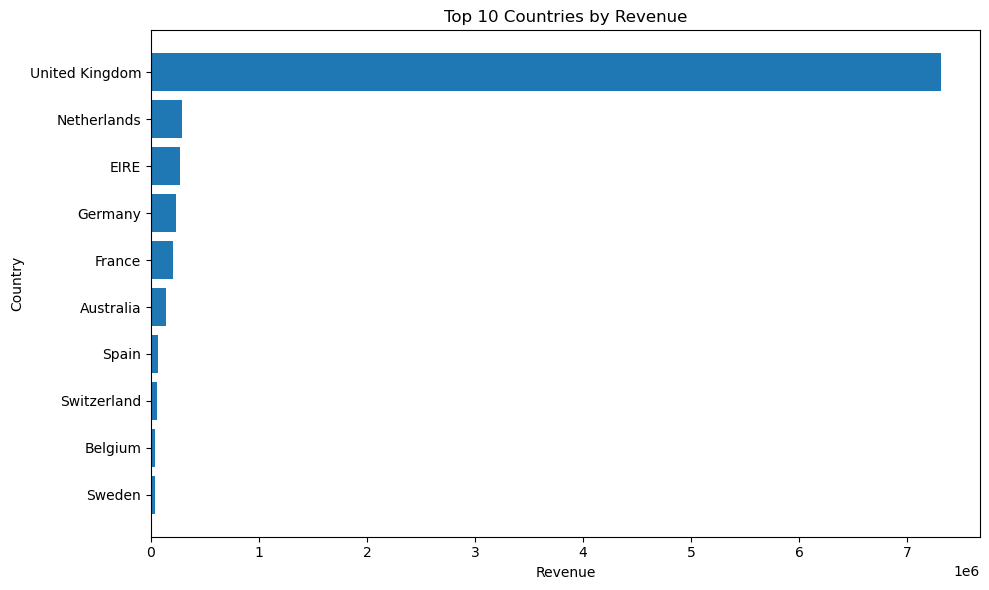

In [12]:
pdf = pdf.sort_values(by="Revenue", ascending=False).head(10)
plt.figure(figsize=(10,6))

plt.barh(pdf["Country"], pdf["Revenue"])

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### Most active customers based in CustomerId

In this step, we identify the customers who place the most orders.
We use a Spark SQL query to group the data by `CustomerID` and count the number of orders using `COUNT(*)`. The results are sorted in descending order so that the most active customers appear at the top. We limit the output to the top 10 customers.

We display the results using `show()` and convert them into a Pandas DataFrame using `toPandas()` for visualization.

In [13]:
result = spark.sql("""
SELECT CustomerID, COUNT(*) as Orders
FROM sales
GROUP BY CustomerID
ORDER BY Orders DESC
LIMIT 10
""")

result.show()
pdf = result.toPandas()

+----------+------+
|CustomerID|Orders|
+----------+------+
|     17841|  7847|
|     14911|  5677|
|     14096|  5111|
|     12748|  4596|
|     14606|  2700|
|     15311|  2379|
|     14646|  2080|
|     13089|  1818|
|     13263|  1677|
|     14298|  1637|
+----------+------+



### Visualization of most active customers based on customerId

Here, we create a horizontal bar chart to visualize the top customers based on the number of orders.
Customer IDs are shown on one axis and the number of orders on the other. We convert the IDs to string for better display and invert the axis so that the most active customer appears at the top.
This chart makes it easy to see which customers contribute the most activity.

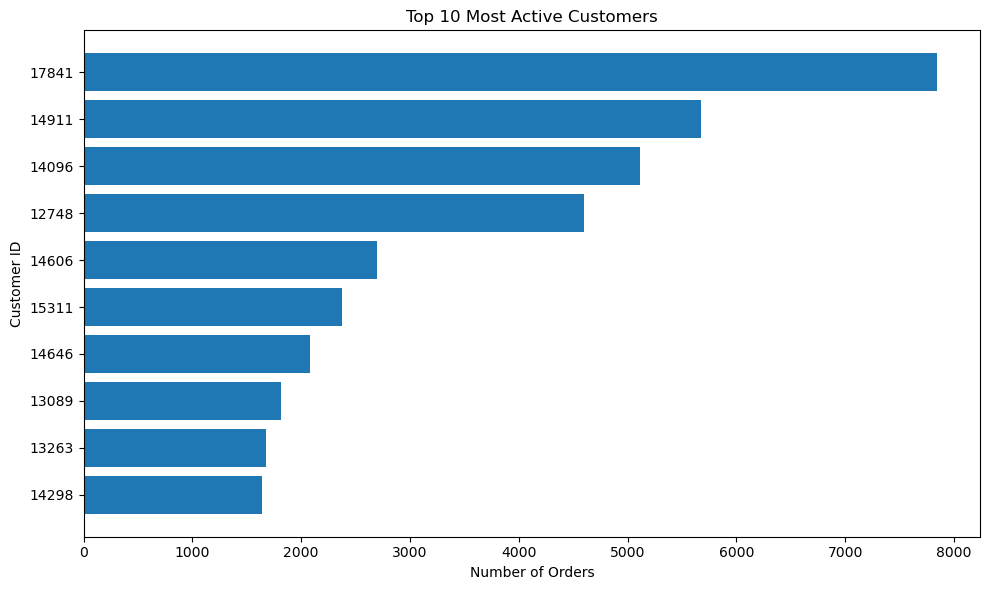

In [14]:
plt.figure(figsize=(10,6))
plt.barh(pdf["CustomerID"].astype(str), pdf["Orders"])
plt.title("Top 10 Most Active Customers")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### Sales Over Time

In this step, we analyze how sales change over time.

We use a Spark SQL query to group the data by `InvoiceDate` and calculate the total sales using `SUM(Quantity)`. The results are ordered by date so we can see the trend clearly over time.

We display the results using `show()` and convert them into a Pandas DataFrame using `toPandas()` for visualization.


In [15]:
result = spark.sql("""
SELECT InvoiceDate, SUM(Quantity) as Total_Sales
FROM sales
GROUP BY InvoiceDate
ORDER BY InvoiceDate
""")

result.show(10)
pdf = result.toPandas()

+---------------+-----------+
|    InvoiceDate|Total_Sales|
+---------------+-----------+
|1/10/2011 10:32|        260|
|1/10/2011 10:35|        408|
|1/10/2011 10:44|         40|
|1/10/2011 10:58|         83|
|1/10/2011 11:09|        249|
|1/10/2011 11:22|        246|
|1/10/2011 11:35|        645|
|1/10/2011 11:38|        386|
|1/10/2011 11:59|         19|
|1/10/2011 12:03|        195|
+---------------+-----------+
only showing top 10 rows


### Visualization of Sales Over Time

Next, we convert the `InvoiceDate` column into a proper date format and sort the data by date.

We then create a line chart to show how total sales change over time. The x-axis represents the date, and the y-axis shows the total sales.

This visualization helps us understand patterns and trends in sales across different time periods.

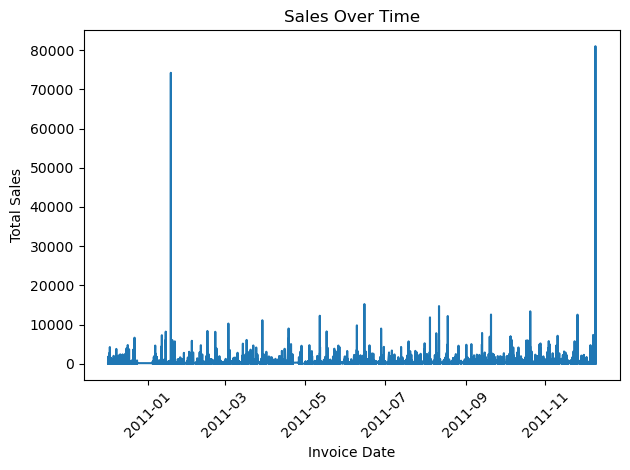

In [16]:
import pandas as pd

pdf["InvoiceDate"] = pd.to_datetime(pdf["InvoiceDate"])
pdf = pdf.sort_values("InvoiceDate")
import matplotlib.pyplot as plt

plt.figure()

plt.plot(pdf["InvoiceDate"], pdf["Total_Sales"])

plt.title("Sales Over Time")
plt.xlabel("Invoice Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Connecting to MongoDB

In this step, we connect our project to MongoDB to store the processed data.

We start by importing `MongoClient` from the PyMongo library. Then, we connect to the local MongoDB server using the default address `mongodb://localhost:27017/`.

Next, we create a database called "bigdata_db" and a collection named "sales" where the data will be stored.

In [18]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["bigdata_db"]
collection = db["sales"]

### Inserting Data into MongoDB

After preparing the data in Spark, we convert the DataFrame into a format suitable for MongoDB. We use `toPandas()` and then convert it into a list of dictionaries using `to_dict("records")`.

Then insert all the data into MongoDB using `insert_many()`.

In [40]:
data = df.toPandas().to_dict("records")

In [41]:
collection.insert_many(data)
print("Data inserted successfully")

Data inserted successfully


### Verifying the Data

To make sure the data is inserted correctly, we check the total number of documents using `count_documents({})`.

In [42]:
collection.count_documents({})

1989620

We also use `find_one()` to display a sample record from the collection. This helps us confirm that the data is stored properly in MongoDB.

In [43]:
collection.find_one()

{'_id': ObjectId('69cfa40f1777fbac1a939e5c'),
 'InvoiceNo': '536365',
 'StockCode': '85123A',
 'Description': 'WHITE HANGING HEART T-LIGHT HOLDER',
 'Quantity': 6,
 'InvoiceDate': '12/1/2010 8:26',
 'UnitPrice': 2.55,
 'CustomerID': 17850,
 'Country': 'United Kingdom'}

## MongoDB Aggregation

### Country Analysis
Here, we perform data analysis directly in MongoDB using aggregation.

We create a pipeline, where we first group the data by country using `$group`. Then, we calculate the total quantity for each country using `$sum`.

After that, we sort the results in descending order using `$sort` so that the countries with the highest sales appear at the top.

We run the aggregation using `collection.aggregate()` and display a few results to check the output.

In [44]:
pipeline = [
    {
        "$group": {
            "_id": "$Country",
            "Total_Quantity": {"$sum": "$Quantity"}
        }
    },
    {
        "$sort": {"Total_Quantity": -1}
    }
]

result = list(collection.aggregate(pipeline))

for r in result[:5]:
    print(r)

{'_id': 'United Kingdom', 'Total_Quantity': 21347360}
{'_id': 'Netherlands', 'Total_Quantity': 1004685}
{'_id': 'EIRE', 'Total_Quantity': 702625}
{'_id': 'Germany', 'Total_Quantity': 596315}
{'_id': 'France', 'Total_Quantity': 557360}


Next, we convert the MongoDB result into a Pandas DataFrame for easier handling.

In [45]:
mongo_df = pd.DataFrame(result)
mongo_df = mongo_df.rename(columns={"_id": "Country"})
mongo_df = mongo_df.sort_values(by="Total_Quantity", ascending=False).head(10)

### Visualizing the Result
We rename the `_id` column to "Country" for better readability and sort the data to get the top 10 countries.Finally, we create a horizontal bar chart to visualize the results and it helps us clearly see which countries have the highest total sales.
This result can be compared with the Spark SQL output to check consistency.

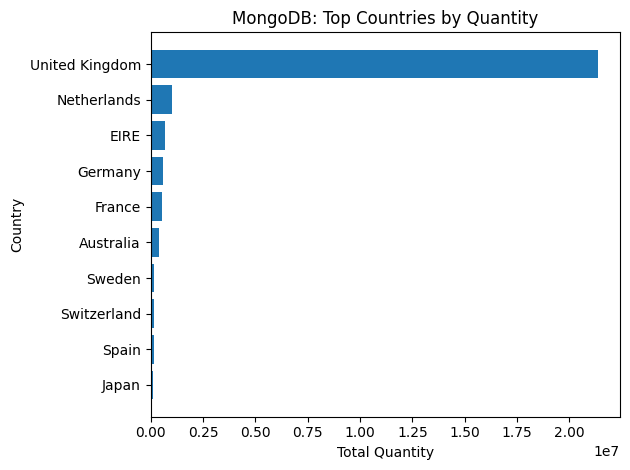

In [46]:
plt.figure()

plt.barh(mongo_df["Country"], mongo_df["Total_Quantity"])

plt.title("MongoDB: Top Countries by Quantity")
plt.xlabel("Total Quantity")
plt.ylabel("Country")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### Revenue by Country
Here, we calculate the revenue generated by each country using MongoDB.

We create an aggregation pipeline where we group the data by country using `$group`. Then, we calculate the total revenue by multiplying Quantity and UnitPrice using `$multiply`, and summing the result using `$sum`.

After that, we sort the results in descending order using `$sort` so that the countries with the highest revenue appear first.

We run the aggregation using `collection.aggregate()` and display a few results to check the output.

In [47]:
pipeline_revenue = [
    {
        "$group": {
            "_id": "$Country",
            "Revenue": {
                "$sum": {
                    "$multiply": ["$Quantity", "$UnitPrice"]
                }
            }
        }
    },
    {
        "$sort": {"Revenue": -1}
    }
]
result = list(collection.aggregate(pipeline_revenue))

for r in result[:5]:
    print(r)

{'_id': 'United Kingdom', 'Revenue': 36541957.77}
{'_id': 'Netherlands', 'Revenue': 1427231.7}
{'_id': 'EIRE', 'Revenue': 1327729.5}
{'_id': 'Germany', 'Revenue': 1144335.7}
{'_id': 'France', 'Revenue': 1045120.25}


In [48]:
mongo_df = pd.DataFrame(result)
mongo_df = mongo_df.rename(columns={"_id": "Country"})
mongo_df = mongo_df.sort_values(by="Revenue", ascending=False).head(10)

### Visualizing the Result
Again we, rename the `_id` column to "Country" and sort the data to get the top 10 countries by revenue.

Finally, we create a horizontal bar chart to visualize the results. This makes it easy to compare revenue across countries.

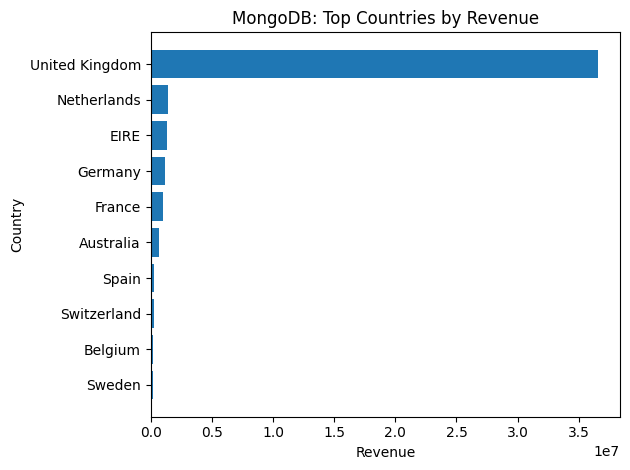

In [49]:
plt.figure()
plt.barh(mongo_df["Country"], mongo_df["Revenue"])

plt.title("MongoDB: Top Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### Top products
Here, we analyze the top-selling products using MongoDB.

We create an aggregation pipeline where we group the data by product description using `$group`. Then, we calculate the total quantity sold for each product using `$sum`.

After that, we sort the results in descending order using `$sort` so that the most sold products appear at the top. We also use `$limit` to select only the top 10 products.

We execute the aggregation using `collection.aggregate()` and display a few results to verify the output.

This analysis helps us identify the most popular products based on total sales.

In [50]:
pipeline_products = [
    {
        "$group": {
            "_id": "$Description",
            "Total_Sold": {"$sum": "$Quantity"}
        }
    },
    {
        "$sort": {"Total_Sold": -1}
    },
    {
        "$limit": 10
    }
]
result = list(collection.aggregate(pipeline_products))

for r in result[:5]:
    print(r)

{'_id': 'PAPER CRAFT , LITTLE BIRDIE', 'Total_Sold': 404975}
{'_id': 'MEDIUM CERAMIC TOP STORAGE JAR', 'Total_Sold': 389580}
{'_id': 'WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'Total_Sold': 272075}
{'_id': 'JUMBO BAG RED RETROSPOT', 'Total_Sold': 230905}
{'_id': 'WHITE HANGING HEART T-LIGHT HOLDER', 'Total_Sold': 183625}


## Performance Comparison (Spark vs MongoDB)

### Measure Spark time
In this step, we measure how long Spark takes to run a query.

We use the `time` module to record the start and end time of the Spark SQL query. The difference between these two values gives us the execution time.

This allows us to compare the performance of Spark SQL with MongoDB aggregation and understand which system processes the data faster.

In [51]:
import time

start = time.time()

spark.sql("""
SELECT Country, SUM(Quantity) as Total_Quantity
FROM sales
GROUP BY Country
ORDER BY Total_Quantity DESC
""").show()

end = time.time()

print("Spark Time:", end - start)

+---------------+--------------+
|        Country|Total_Quantity|
+---------------+--------------+
| United Kingdom|       4269472|
|    Netherlands|        200937|
|           EIRE|        140525|
|        Germany|        119263|
|         France|        111472|
|      Australia|         84209|
|         Sweden|         36083|
|    Switzerland|         30083|
|          Spain|         27951|
|          Japan|         26016|
|        Belgium|         23237|
|         Norway|         19338|
|       Portugal|         16122|
|        Finland|         10704|
|Channel Islands|          9491|
|        Denmark|          8235|
|          Italy|          8112|
|         Cyprus|          6361|
|      Singapore|          5241|
|        Austria|          4881|
+---------------+--------------+
only showing top 20 rows
Spark Time: 0.7695882320404053


### Measuring MongoDB Execution time
In this step, we measure how long MongoDB takes to run the aggregation query.

We use the `time` module to record the start time before running the aggregation pipeline. Then, after executing the query using `collection.aggregate()`, we record the end time.

The difference between the end time and start time gives us the total execution time for MongoDB.

This helps us compare the performance of MongoDB with Spark SQL and understand how each system handles data processing.

In [52]:
start = time.time()

list(collection.aggregate(pipeline))

end = time.time()

print("MongoDB Time:", end - start)

MongoDB Time: 2.9288742542266846


**Insight:** MongoDB performs well for structured queries on stored data, while Spark is better suited for large-scale distributed processing.


# Thank You!😊